In [17]:
import importlib
import numpy as np
import os
import EEGNet_Eneriz_2 as EEG
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
samples,labels,subjects = EEG.LoadDatabase(r'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet',Channels=64)

# Entrenamiento con FFT a lo bruto. Lo normal es q no salga nada


In [ ]:
transform = np.fft.rfft(samples, axis=2)

Samples = transform.shape[2]
Channels, nb_classes, ds = 64, 4, 1

folds=5

#Parámetros de entrenamiento : LR, epochs, batchSize, verbose

def lr_schedule(epoch):
    if epoch < 20: return 1e-2
    elif epoch < 40: return 2e-3
    elif epoch < 60: return 2e-4
    elif epoch < 80: return 4e-6
    else: return 4e-8

epochs, batch_size, verbose = 100, 16, 1




#--------------------------------------------------------
#TRANSFORMAR LOS DATOS (seleccionar canales, downSampling, ventana temporal)
#--------------------------------------------------------


#--------------------------------------------------------
#CALCULO DEL CV. Se guarda en una carpeta los pesos de todos los folds, y las métricas acc y val_acc. Aqui de momento paso los datos pelados, sin transformar
#--------------------------------------------------------
o_weights_folder=fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train"
acc,val_acc = EEG.cvTrain(folds,transform,labels,subjects,outputFolder=o_weights_folder,lr_schedule=lr_schedule,epochs=epochs,Channels=Channels,Samples=Samples)




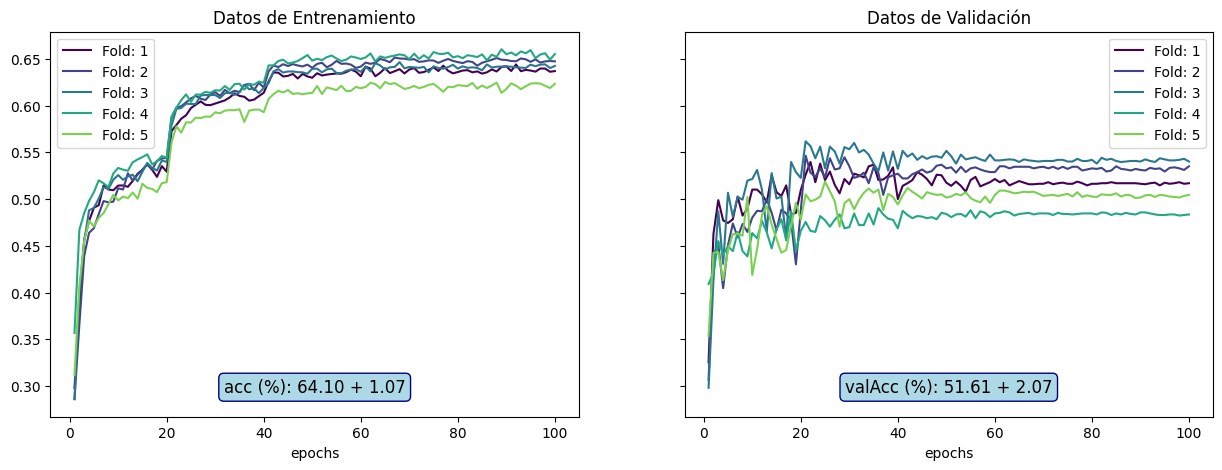

In [15]:
EEG.plotCvHistory(5,o_weights_folder)

In [16]:
#-------------------------------------------------------------------------------------------
#Entrenamiento de sujeto específico.
#-------------------------------------------------------------------------------------------
importlib.reload(EEG)


epochs=5
folds=4

#Es para saber qué pesos del modelo global usar de partida
def val_fold(subjectSpecific):
    if   subjectSpecific < 22: return 0
    elif subjectSpecific < 43: return 1
    elif subjectSpecific < 64: return 2
    elif subjectSpecific < 85: return 3
    else: return 4



#samples,labels,subjects = EEG.LoadDatabase(r"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\Physionet",Channels)



for subjectSpecific in np.unique(subjects):


    valFold = val_fold(subjectSpecific)
    print(f'sujeto: {subjectSpecific:.0f} || valFold: {valFold:.0f}')
    
    weightsFile = fr'C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold{valFold:.0f}.weights.h5'
    o_weights_folder=fr"C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\subjectSpecificFFT\subjectSpecific{subjectSpecific:.0f}_cv{folds:.0f}_chan{Channels:.0f}_samples{Samples:.0f}_nbClasses{nb_classes}_ds{ds:.0f}"

    subjectSpecific_samples, subjectSpecific_labels, subjectSpecific_subjects = EEG.subjectSpecificData(subjectSpecific,transform,labels,subjects)
    EEG.cvTrain(folds,subjectSpecific_samples,subjectSpecific_labels,subjectSpecific_subjects,o_weights_folder,weightsFile,lr_schedule,epochs=epochs,Channels=Channels,Samples=Samples,verbose=0)



sujeto: 1 || valFold: 0
Fold 0: sujetos validación: 1.0 - 1.0


c:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\EEGNet_Eneriz_2.py:110: ComplexWarning: Casting complex values to real discards the imaginary part
  X_cv5[i] = samples[ i*int(len(samples[:,0,0])/folds) : (i+1)*int(len(samples[:,0,0])/folds)]
c:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold0.weights.h5
Pesos cargados del archivo : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold0.weights.h5
Usando Learning Rate Scheduler : <function lr_schedule at 0x000002760ECF9580>
accuracy en train: 0.762 || accuracy en val: 0.762
Fold 1: sujetos validación: 1.0 - 1.0
Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold0.weights.h5
Pesos cargados del archivo : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold0.weights.h5
Usando Learning Rate Scheduler : <function lr_schedule at 0x000002760ECF9580>
accuracy en train: 0.825 || accuracy en val: 0.381
Fold 2: sujetos validación: 1.0 - 1.0
Pesos cargados desde : C:\Users\Manuel Morato Miguel\Desktop\EEG\EEGNet\arl-eegmodels-master\FFT_train\pesos_fold0.weights.h5
Pesos cargados del archi